# 🧪 Data Quality Scorecard

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-accelerator/data-quality-scorecard/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-accelerator/data-quality-scorecard/demo.ipynb)

> **Pain point:** *We don't know how bad our data is.*

"Is our data good enough?" usually gets a shrug. This turns the shrug into a **0-100 score with a letter grade**, broken down across six quality dimensions, plus a ranked list of exactly what to fix first.

**What this notebook covers**
1. The six dimensions and how they're scored
2. A deliberately messy sample dataset
3. The headline score + grade
4. The per-dimension breakdown
5. The ranked issues list — what to fix first


## Step 1 — Six dimensions, one score

Each column is checked against six Great-Expectations-inspired dimensions, then rolled up into a single weighted score:

| Dimension | Asks | Weight |
|-----------|------|--------|
| Completeness | How few missing values? | 25% |
| Validity | Right type / range / format? | 25% |
| Uniqueness | How few duplicate rows? | 15% |
| Consistency | Categories not fragmented by case/space? | 15% |
| Timeliness | Dates not stale or future? | 10% |
| Distribution | Numerics not dominated by outliers? | 10% |

All native pandas + numpy — no heavy dependency, no API keys.

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from quality import (
    WEIGHTS,
    checks_to_frame,
    sample_dirty_data,
    score_dataframe,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Weights:', WEIGHTS)

Weights: {'completeness': 0.25, 'uniqueness': 0.15, 'validity': 0.25, 'consistency': 0.15, 'timeliness': 0.1, 'distribution': 0.1}


## Step 2 — A deliberately messy dataset

`sample_dirty_data()` plants real problems on purpose: invalid emails, country names fragmented by casing/whitespace (`USA` / `usa` / ` USA `), missing amounts, negative and outlier values, stale dates, and duplicate rows — so the scorecard has something to catch.

In [2]:
df = sample_dirty_data()
print(f'{len(df)} rows x {df.shape[1]} columns')
df.head()

510 rows x 5 columns


,customer_id,email,country,amount,signup_date
0,1000,user0@example.com,canada,97.11,2024-12-23
1,1001,user1@example.com,canada,133.84,2025-12-16
2,1002,user2@example.com,Canada,31.58,2025-06-10
3,1003,user3@example.com,UK,55.10,2025-02-27
4,1004,not-an-email,USA,72.31,2024-04-25


## Step 3 — The headline score

One call runs all six dimensions and returns an overall score + letter grade.

In [3]:
card = score_dataframe(df)
print(f'OVERALL: {card.overall} / 100   ->   Grade {card.grade}')
print(f'({card.n_rows} rows, {card.n_cols} columns scored)')

OVERALL: 87.9 / 100   ->   Grade B
(510 rows, 5 columns scored)


## Step 4 — The per-dimension breakdown

Where exactly is the data weak? The breakdown points straight at it.

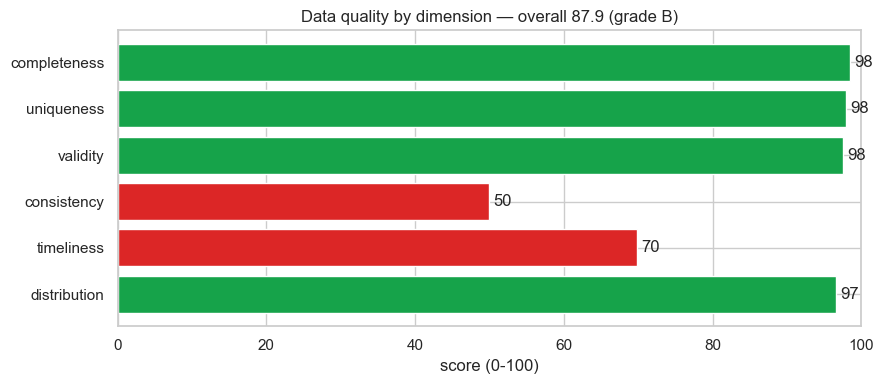

In [4]:
dims = list(card.dimension_scores.keys())
scores = [card.dimension_scores[d] for d in dims]

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#16A34A' if s >= 90 else '#F59E0B' if s >= 70 else '#DC2626'
          for s in scores]
bars = ax.barh(dims[::-1], scores[::-1], color=colors[::-1])
ax.set_xlim(0, 100)
ax.set_xlabel('score (0-100)')
ax.bar_label(bars, fmt='%.0f', padding=3)
ax.set_title(f'Data quality by dimension — overall {card.overall} (grade {card.grade})')
plt.tight_layout()
plt.savefig('scorecard.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — What to fix first

The scorecard ranks the worst offenders so a data team knows where to spend the next hour.

In [5]:
for issue in card.issues:
    print(' -', issue)

 - [consistency] country: 3 variant(s) differ only by case/space (50.0)
 - [timeliness] signup_date: 0% future-dated, 60% older than 365d (69.8)
 - [validity] email: 12.2% invalid emails (87.8)
 - [completeness] amount: 7.6% missing (92.4)
 - [distribution] amount: 1.7% extreme outliers (93.2)


The full per-check report (every column × dimension), worst first:

In [6]:
checks_to_frame(card).sort_values('score').head(12)

,dimension,column,score,detail
11,consistency,country,50.0,3 variant(s) differ only by case/space
12,timeliness,signup_date,69.8,"0% future-dated, 60% older than 365d"
7,validity,email,87.8,12.2% invalid emails
3,completeness,amount,92.4,7.6% missing
14,distribution,amount,93.2,1.7% extreme outliers
5,uniqueness,<rows>,98.0,10 duplicate rows
0,completeness,customer_id,100.0,no missing values
1,completeness,email,100.0,no missing values
2,completeness,country,100.0,no missing values
4,completeness,signup_date,100.0,no missing values


## Summary

The messy sample lands around a **grade B** — dragged down by inconsistent country casing and stale dates, exactly as planted. Run this on a real table and you get a defensible quality number, a breakdown that shows *where* it's weak, and a fix list — the start of a data-quality SLA instead of a shrug.

## 🔧 Try your own

Uncomment and point it at your own CSV:

In [7]:
# import pandas as pd
# my_df = pd.read_csv('your_data.csv')
# card = score_dataframe(my_df)
# print('Score:', card.overall, 'Grade:', card.grade)
# for issue in card.issues:
#     print(' -', issue)

---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** — Day 28 of the 60-day FDE portfolio.

**Run the Streamlit version:**
```bash
pip install -r requirements.txt
streamlit run app.py
```